# DTAT341 deeptrack.sequences

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/3-advanced-topics/DTAT341_sequences.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

This advanced tutorial introduces the module deeptrack.sequences.

## 1. What is a sequence?

Sequences are lists of images, where any image in the series may depend on previous images. They can be used to create videos. They can also be used to resolve the same feature-set several times, changing only a subset of the properties of the features; an example would be imaging a sample at several focal planes.

To resolve a sequence, you create an instance of the feature `Sequence`, with the feature you want to resolve as the first input, and `sequence_length` as a second input. 

By default, properties remain constant in a series. This means that each step in the sequence is by default the same.

To make the properties change, you should call the method `myfeature.to_sequential()` for the feature you want to change during the sequence, and a set of functions as keyword arguments. These functions will be converted to instances of `SequentialProperty`, which behave similarly to regular properties. For more information about how sequential properties work, see [properties_example.ipynb](properties_example.ipynb).

## 2. Example - A rotating ellipse
To demonstrate the concept of `sequences`, we will implement a simple case of a rotating ellipse.

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


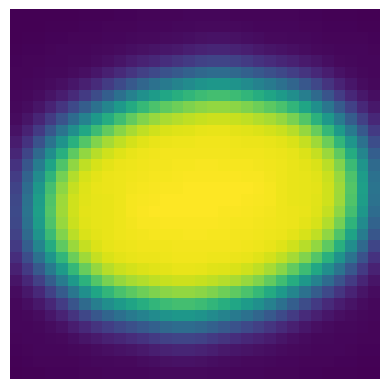

In [1]:
from deeptrack.optics import Fluorescence
from deeptrack.scatterers import Ellipse
from deeptrack.sequences import Sequence

import numpy as np

# Define optics.
optics = Fluorescence(
    NA=0.6,
    magnification=10,
    resolution=1e-6,
    wavelength=633e-9,
    output_region=(0, 0, 32, 32),
)

# Define scatterer
ellipse = Ellipse(
    position_unit="pixel",
    position=(16, 16),
    intensity=1,
    radius=(1.5e-6, 1e-6),
    rotation=0, # This will be the value at time 0.
)

# Define function which will give give the next property values for a given feature.
def get_rotation(sequence_length, previous_value):
    delta = 2 * np.pi / sequence_length
    return previous_value + delta

# Make scatterer sequential by specifying the properties to be sequentially
# evaluated as arguments in ellipse.to_sequential(), for this case it is
# rotation of the ellipse. 

rotating_ellipse = ellipse.to_sequential(rotation=get_rotation)    

# Image the sequential ellipse with the microscope. 
imaged_rotating_ellipse = optics(rotating_ellipse)

# Encapsulate as a Sequence object by specifying duration.
imaged_rotating_ellipse_sequence = Sequence(imaged_rotating_ellipse,
                                            sequence_length=50)

imaged_rotating_ellipse_sequence.update().plot()

## 3. Example - Brownian Motion
A more advanced application of `sequences` is to simulate Brownian motion and obtain a movie from this.

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


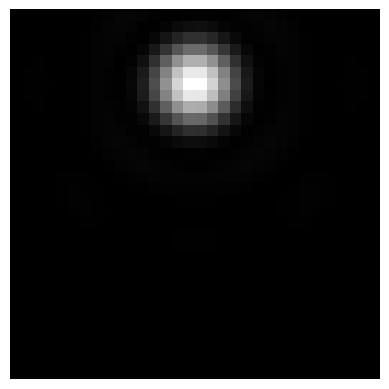

In [2]:
from deeptrack.scatterers import Sphere

# Define scatterer
particle = Sphere(
    position_unit="pixel",
    position=(16, 16),
    radius=(.1e-6),
    intensity=1,
)

# Define function to update the scatterers position property with normally distributed perturbations.
def update_position(sequence_length, previous_value):
    delta = np.random.standard_normal(2)*0.6
    return previous_value + delta

brownian_particle = particle.to_sequential(position=update_position)    

# Image the particle with the microscope. 
imaged_brownian_particle = optics(brownian_particle)

# Encapsulate as a Sequence object by specifying duration.
imaged_brownian_particle_sequence = Sequence(imaged_brownian_particle,
                                            sequence_length=50)

imaged_brownian_particle_sequence.update().plot(cmap="gray")

## 3.1 Chaining
You can also use the chain operator when imaging the brownian particle as a sequence, which will produce scatterers that are updated independently of each other.

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


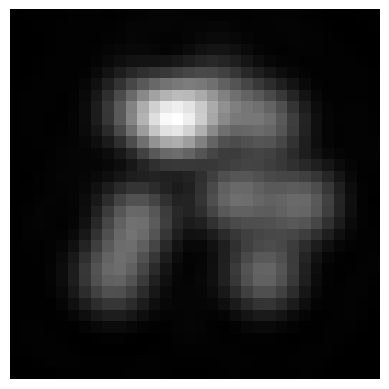

In [3]:
# Chain multiple particles with ^
imaged_brownian_particle = optics(brownian_particle^10)

# Encapsulate as a Sequence object by specifying duration.
imaged_brownian_particle_sequence = Sequence(imaged_brownian_particle,
                                            sequence_length=100)

imaged_brownian_particle_sequence.update().plot(cmap="gray")

## 4. Example - A Microscope Sequence
Sequences are not exclusive to scatterers, you can in practice sequentially evaluate the properties of any feature in `DeepTrack2`, including microscopes. This example will show how you can vary the wavelength property.


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


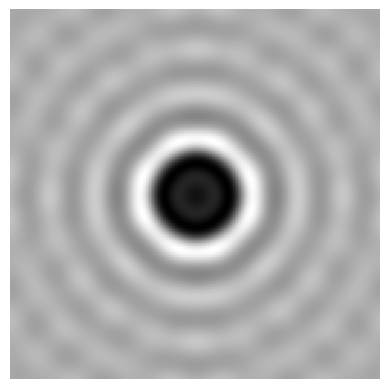

In [ ]:
from deeptrack.optics import Brightfield

# Define optics.
optics = Brightfield(
    NA=0.6,
    magnification=10,
    resolution=1e-6,
    wavelength=400e-9,
    output_region=(0, 0, 128, 128),
)

# Define scatterer
particle = Sphere(
    position_unit="pixel",
    position=(64, 64),
    radius=(1e-6),
    intensity=1,
)

# Define function to update the microscope wavelength with constant increments.
def update_wavelength(sequence_length, previous_value):
    delta = 5e-9
    return previous_value + delta

microscope_sequence = optics.to_sequential(wavelength=update_wavelength)    

# Image the particle with the microscope. 
variable_microscope = optics(particle)

# Encapsulate as a Sequence object by specifying duration.
imaged_microscope_sequence= Sequence(variable_microscope,
                                            sequence_length=100)

imaged_microscope_sequence.update().plot(cmap="gray")